In [1]:
#importing libraries
import pandas as pd
import requests
import time
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
import re

In [2]:
#loading the data and filtering this (in terms of realistic-ness)
df = pd.read_csv('evaluation_results3.csv')

df['Realistic?'] = df['Realistic?'].fillna('Yes')
df = df[df['Realistic?'].str.contains('Yes', case=False, na=False)]

print(f"Loaded {len(df)} realistic requests.")

Loaded 1412 realistic requests.


In [3]:
# extracting levels

def extract_levels(value):
    if pd.isna(value) or value == 'Original Request':
        return None, None
    if ' + ' in value:
        parts = value.split(' + ')
        if len(parts) == 2:
            seniority = parts[0].strip().title()
            raw_hastiness = parts[1].strip().title().split('(')[0].strip()
            
            if 'Very Hasty' in raw_hastiness:
                hastiness = 'Very Hasty'
            elif 'Hasty' in raw_hastiness:
                hastiness = 'Hasty'
            elif 'Neutral' in raw_hastiness:
                hastiness = 'Neutral'
            elif 'Formal' in raw_hastiness:
                hastiness = 'Formal'
            elif 'Very Formal' in raw_hastiness:
                hastiness = 'Very Formal'
            else:
                hastiness = raw_hastiness
            return seniority, hastiness
    return None, None

In [4]:
df['Seniority'] = df['Variation Value'].apply(lambda x: extract_levels(x)[0])
df['Hastiness'] = df['Variation Value'].apply(lambda x: extract_levels(x)[1])
df = df.dropna(subset=['Hastiness'])

print(f"Combination Variation Rows: {len(df)}")

Combination Variation Rows: 1308


In [5]:
#cleaning text (removing stopwords)
STOPWORDS = set([
    'to', 'for', 'the', 'of', 'and', 'in', 'on', 'at', 'with', 'by', 'from', 
    'as', 'is', 'was', 'we', 'our', 'us', 'i', 'you', 'this', 'that', 
    'these', 'those', 'a', 'an', 'data', 'access', 'request', 'will', 'can',
    'use', 'used', 'using', 'analysis', 'analyze', 'help', 'make', 'need',
    'would', 'could', 'should', 'may', 'might', 'must', 'shall', 'also',
    'well', 'better', 'good', 'great', 'really', 'very', 'even'
])

def clean_text(text):
    if not isinstance(text, str):
        return []
    text = text.lower()
    words = re.findall(r'\b[a-z]+\b', text)
    return [w for w in words if w not in STOPWORDS and len(w) > 1]

df['Clean_Words'] = df['Purpose'].apply(clean_text)

In [6]:
#getting the ngrams baseline frequencies (using the link Linus gave you)
def get_ngrams_freq(word):

    try:
        url = f"https://api.ngrams.dev/eng/search?query={word}&flags=cr"
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get('ngrams'):
                return data['ngrams'][0].get('relTotalMatchCount', 0)
    except Exception as e:
        pass
    return 0

In [7]:
# Cache to avoid repeated/duplicate API calls for the same word
ngram_cache = {}

def get_ngrams_freq_cached(word):
    if word in ngram_cache:
        return ngram_cache[word]
    freq = get_ngrams_freq(word)
    ngram_cache[word] = freq
    time.sleep(0.15)  # polite delay between calls
    return freq

In [8]:
all_words = [w for words in df['Clean_Words'] for w in words]
unique_words = list(set(all_words))

print(f"Fetching baseline frequencies for {len(unique_words)} words...")
ngram_baseline = {}
for i, word in enumerate(unique_words):
    if i % 20 == 0:
        print(f"Progress: {i}/{len(unique_words)}")
    ngram_baseline[word] = get_ngrams_freq(word)
    time.sleep(0.15)

print(f"Done. Fetched {len(ngram_baseline)} baseline frequencies.")

Fetching baseline frequencies for 2396 words...
Progress: 0/2396
Progress: 20/2396
Progress: 40/2396
Progress: 60/2396
Progress: 80/2396
Progress: 100/2396
Progress: 120/2396
Progress: 140/2396
Progress: 160/2396
Progress: 180/2396
Progress: 200/2396
Progress: 220/2396
Progress: 240/2396
Progress: 260/2396
Progress: 280/2396
Progress: 300/2396
Progress: 320/2396
Progress: 340/2396
Progress: 360/2396
Progress: 380/2396
Progress: 400/2396
Progress: 420/2396
Progress: 440/2396
Progress: 460/2396
Progress: 480/2396
Progress: 500/2396
Progress: 520/2396
Progress: 540/2396
Progress: 560/2396
Progress: 580/2396
Progress: 600/2396
Progress: 620/2396
Progress: 640/2396
Progress: 660/2396
Progress: 680/2396
Progress: 700/2396
Progress: 720/2396
Progress: 740/2396
Progress: 760/2396
Progress: 780/2396
Progress: 800/2396
Progress: 820/2396
Progress: 840/2396
Progress: 860/2396
Progress: 880/2396
Progress: 900/2396
Progress: 920/2396
Progress: 940/2396
Progress: 960/2396
Progress: 980/2396
Progress

In [9]:
def compute_deviation_scores(dataframe, group_col, baseline_dict, min_count=3):
    """
    For each level in group_col (e.g. Hastiness or Seniority):
    - count word frequencies within that category
    - compare to precomputed baseline_dict frequencies
    - compute log-ratio, then z-score within the category
    """
    results = {}

    for level in dataframe[group_col].dropna().unique():
        subset = dataframe[dataframe[group_col] == level]

        all_words = [w for word_list in subset['Clean_Words'] for w in word_list]
        counts = Counter(all_words)
        total_words = sum(counts.values())

        log_ratios = {}
        for word, count in counts.items():
            if count < min_count:
                continue

            observed_freq = count / total_words
            baseline_freq = baseline_dict.get(word, 0)

            if baseline_freq == 0:
                baseline_freq = 1e-9  # floor so log doesn't blow up for unseen words

            log_ratios[word] = np.log(observed_freq / baseline_freq)

        # z-score within this category
        values = np.array(list(log_ratios.values()))
        mean, std = values.mean(), values.std()

        z_scores = {
            word: (val - mean) / std if std > 0 else 0
            for word, val in log_ratios.items()
        }

        results[level] = z_scores
        print(f"Processed {level}: {len(z_scores)} words scored")

    return results

In [10]:
import numpy as np

hastiness_scores = compute_deviation_scores(df, 'Hastiness', ngram_baseline)
seniority_scores = compute_deviation_scores(df, 'Seniority', ngram_baseline)

Processed Very Hasty: 700 words scored
Processed Neutral: 866 words scored
Processed Formal: 1049 words scored
Processed Intern: 794 words scored
Processed Junior Analyst: 805 words scored
Processed Senior Manager: 850 words scored
Processed Executive/Ceo: 823 words scored


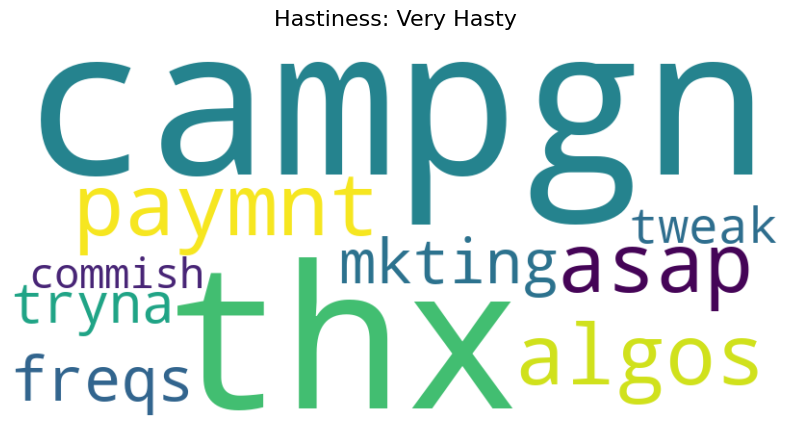

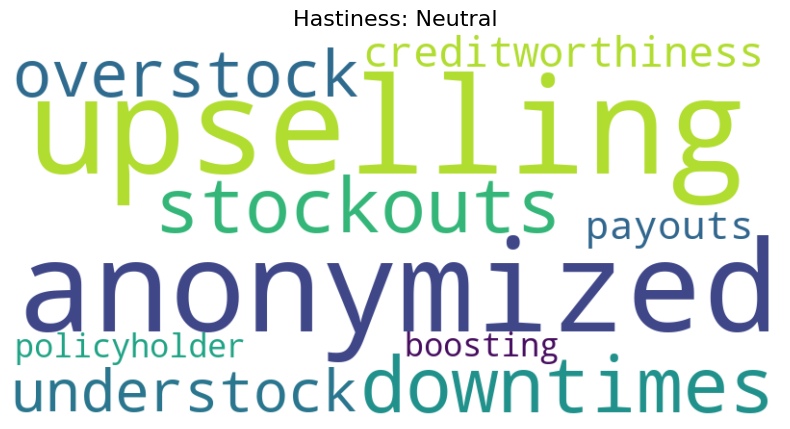

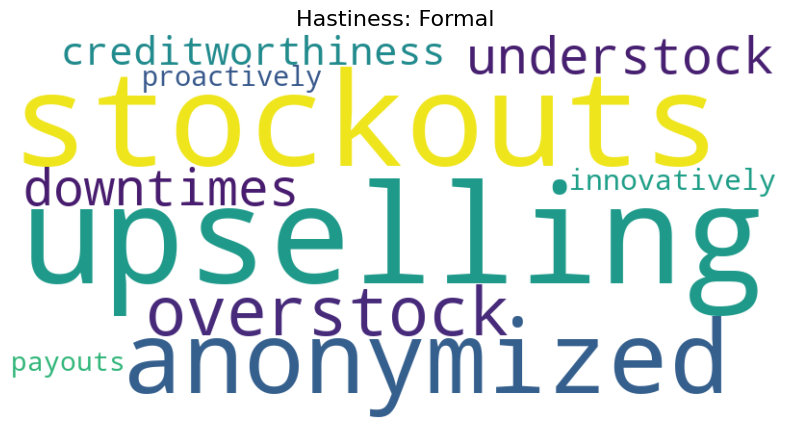

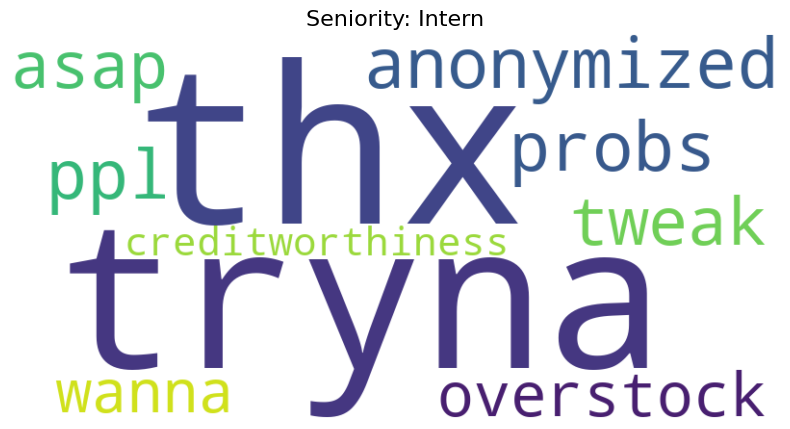

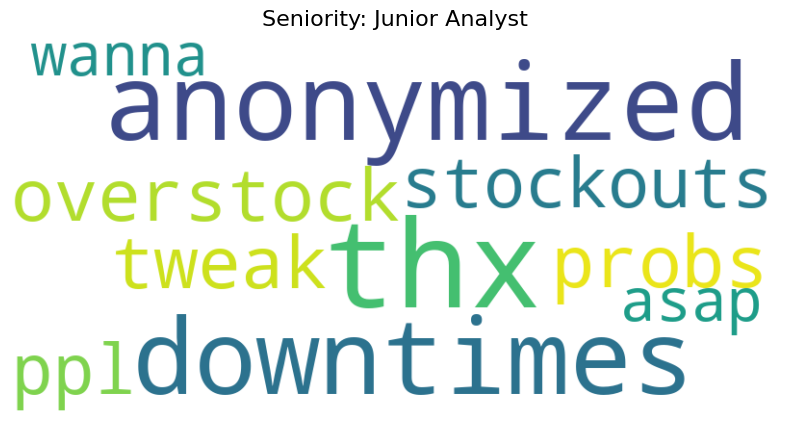

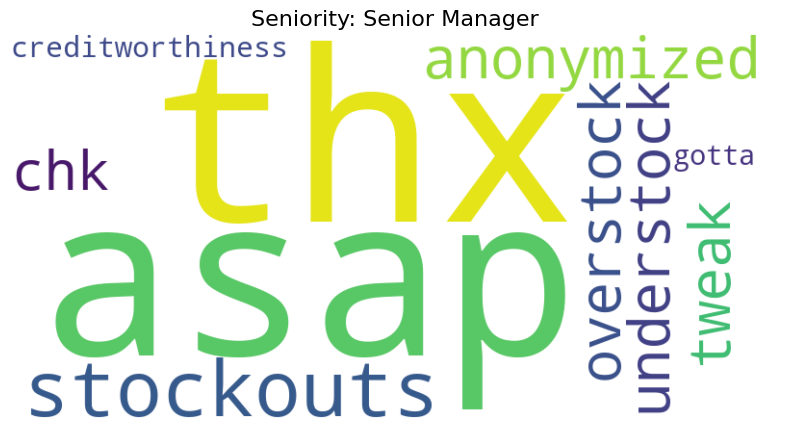

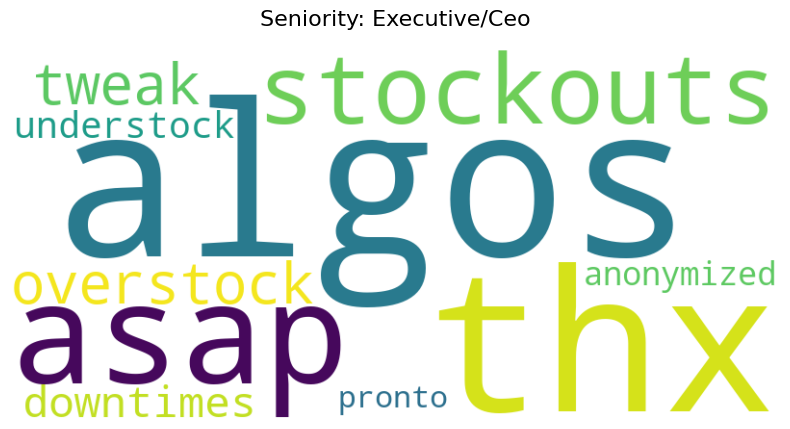

In [11]:
#plotting the wordcloud

def plot_wordcloud(z_scores, title, top_n=10):
    top_words = dict(sorted(z_scores.items(), key=lambda x: x[1], reverse=True)[:top_n])

    min_val = min(top_words.values())
    if min_val <= 0:
        shift = abs(min_val) + 1
        top_words = {w: v + shift for w, v in top_words.items()}

    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis')
    wc.generate_from_frequencies(top_words)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

for level, scores in hastiness_scores.items():
    plot_wordcloud(scores, f"Hastiness: {level}")

for level, scores in seniority_scores.items():
    plot_wordcloud(scores, f"Seniority: {level}")

In [12]:
zero_count = sum(1 for v in ngram_baseline.values() if v == 0)
print(f"{zero_count} / {len(ngram_baseline)} words had zero baseline frequency")

1 / 2396 words had zero baseline frequency


In [13]:
def build_comparison_table(scores_dict, top_n=10):
    """
    Takes a dict of {category_level: {word: z_score}} and returns
    a DataFrame with top_n words + z-scores per category, side by side.
    """
    table_data = {}
    
    for level, z_scores in scores_dict.items():
        top_words = sorted(z_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
        # store as "word (z-score)" pairs in ranked order
        table_data[level] = [f"{word} ({z:.2f})" for word, z in top_words]
    
    # pad shorter lists in case some categories have fewer than top_n words
    max_len = max(len(v) for v in table_data.values())
    for level in table_data:
        table_data[level] += [''] * (max_len - len(table_data[level]))
    
    df_table = pd.DataFrame(table_data)
    df_table.index = [f"Rank {i+1}" for i in range(max_len)]
    return df_table

In [14]:
hastiness_table = build_comparison_table(hastiness_scores, top_n=10)
seniority_table = build_comparison_table(seniority_scores, top_n=10)

print("Hastiness — Top Overused Words by Category")
display(hastiness_table)

print("\nSeniority — Top Overused Words by Category")
display(seniority_table)

Hastiness — Top Overused Words by Category


,Very Hasty,Neutral,Formal
Rank 1,campgn (4.36),upselling (4.00),upselling (4.02)
Rank 2,thx (4.03),anonymized (3.71),stockouts (3.65)
Rank 3,paymnt (3.54),downtimes (3.59),anonymized (3.56)
Rank 4,algos (3.40),stockouts (3.54),overstock (3.51)
Rank 5,asap (3.23),overstock (3.43),downtimes (3.44)
Rank 6,mkting (3.23),understock (3.41),understock (3.42)
Rank 7,freqs (3.19),creditworthiness (3.03),creditworthiness (2.88)
Rank 8,tryna (3.17),payouts (2.63),innovatively (2.79)
Rank 9,tweak (3.16),policyholder (2.59),proactively (2.74)
Rank 10,commish (3.10),boosting (2.52),payouts (2.63)



Seniority — Top Overused Words by Category


,Intern,Junior Analyst,Senior Manager,Executive/Ceo
Rank 1,thx (4.72),thx (4.74),thx (4.07),algos (3.83)
Rank 2,tryna (4.02),anonymized (3.64),asap (3.63),thx (3.77)
Rank 3,anonymized (3.56),downtimes (3.52),stockouts (3.49),asap (3.48)
Rank 4,probs (3.50),overstock (3.47),anonymized (3.42),stockouts (3.38)
Rank 5,ppl (3.47),probs (3.42),understock (3.37),overstock (3.34)
Rank 6,tweak (3.28),tweak (3.38),tweak (3.34),tweak (3.31)
Rank 7,asap (3.15),stockouts (3.35),overstock (3.34),downtimes (3.29)
Rank 8,overstock (3.05),ppl (3.34),chk (2.98),understock (3.26)
Rank 9,wanna (2.87),asap (3.01),creditworthiness (2.73),anonymized (3.19)
Rank 10,creditworthiness (2.82),wanna (2.90),gotta (2.59),pronto (2.80)


In [17]:
#plotting graphs  with this
# Define the correct continuum order for each dimension
hastiness_order = ['Very Hasty', 'Hasty', 'Neutral', 'Formal', 'Very Formal']
seniority_order = ['Intern', 'Junior Analyst', 'Senior Manager', 'Executive/Ceo']

# filter to only the levels that actually exist in your data, in the right order
hastiness_order = [lvl for lvl in hastiness_order if lvl in hastiness_scores]
seniority_order = [lvl for lvl in seniority_order if lvl in seniority_scores]

def plot_word_trends(scores_dict, level_order, words_to_plot, title):
    """
    Plots z-score trends for specific words across an ordered continuum
    (e.g. hastiness or seniority levels).
    """
    plt.figure(figsize=(10, 6))

    for word in words_to_plot:
        y_vals = [scores_dict[level].get(word, np.nan) for level in level_order]
        plt.plot(level_order, y_vals, marker='o', label=word)

    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.xlabel(title.split(' by ')[-1])
    plt.ylabel('Z-score (deviation from baseline)')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_').lower()}.png", dpi=200, bbox_inches='tight')
    plt.show()


In [18]:
def get_top_words_across_all(scores_dict, top_n=8):
    """
    Gets the union of the top N words from each category, so the
    line graph shows the words that matter most somewhere in the continuum.
    """
    top_words = set()
    for z_scores in scores_dict.values():
        top = sorted(z_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
        top_words.update(w for w, _ in top)
    return list(top_words)
    

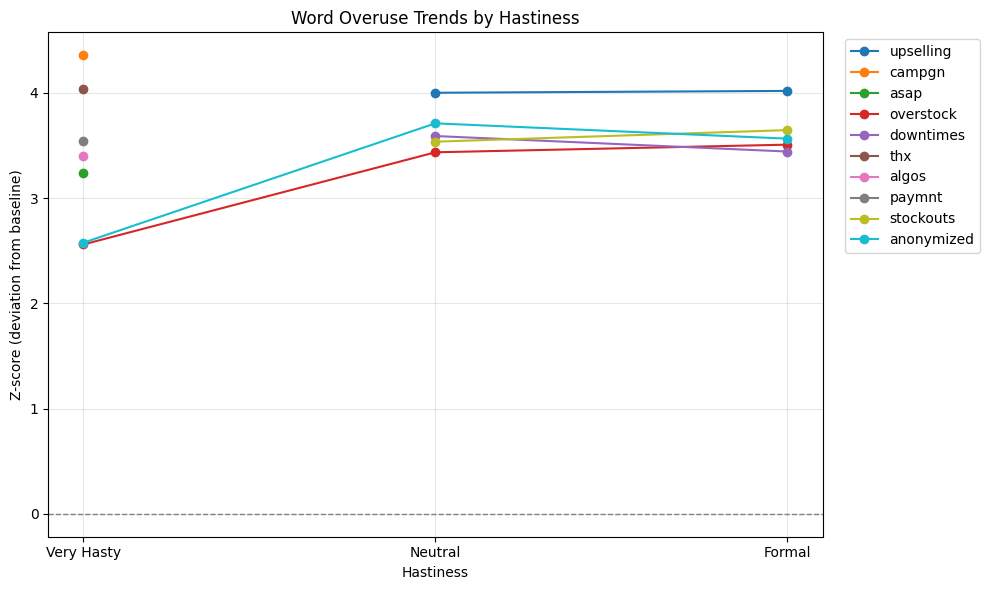

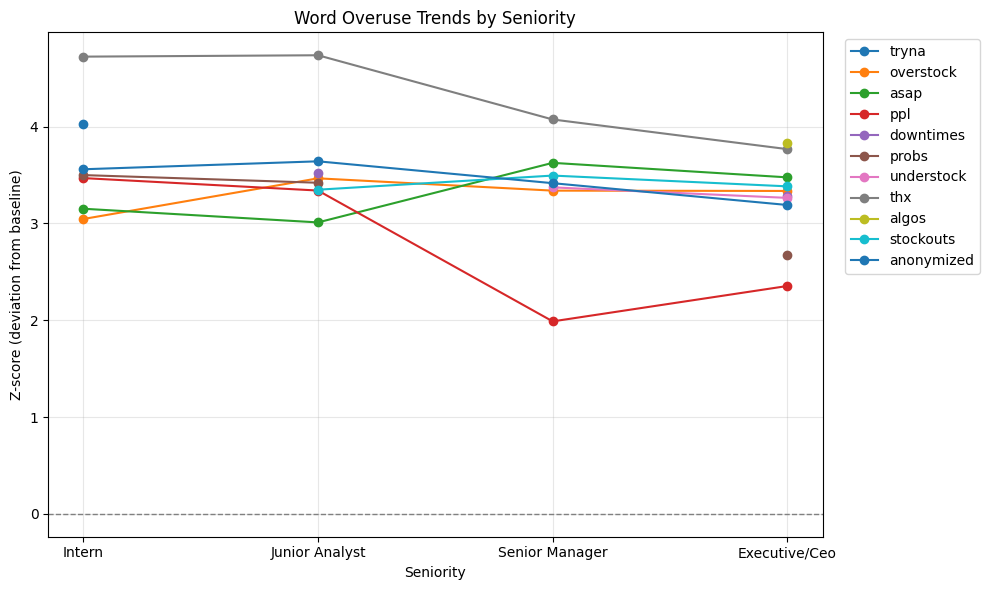

In [19]:
hastiness_words = get_top_words_across_all(hastiness_scores, top_n=5)
plot_word_trends(hastiness_scores, hastiness_order, hastiness_words, 
                  "Word Overuse Trends by Hastiness")

seniority_words = get_top_words_across_all(seniority_scores, top_n=5)
plot_word_trends(seniority_scores, seniority_order, seniority_words, 
                  "Word Overuse Trends by Seniority")